In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib as mpl
import h5py
import numpy as np
import json
from datetime import datetime

In [2]:
def projectDistZ(x1,x2,y1,y2,d12,z):
    mx = (x2-x1)/d12
    xProj = x1 + mx * z
    
    my = (y2-y1)/d12
    yProj = y1 + my * z
    
    return (xProj, yProj)

def get_theta_angles(x1, y1, x2, y2, d):
    import numpy as np
    thetaX = np.arctan((x2-x1)/d) #rad
    thetaY = np.arctan((y2-y1)/d) #rad
    return (thetaX, thetaY)

    
def file_loader(runs):
    from collections.abc import Iterable

    if not isinstance(runs, Iterable):
        runs = [runs]

    pos = []
    phs = []
    tmis = []
    qtots = []
    nclus = []
    info_pluss = []
    xinfos = []
    n_spill_list = []

    for run_number in runs:
        data_path = f'/eos/project/i/insulab-como/testBeam/TB_2025_06_T9_epBOOST/HDF5/run{run_number}.h5'
        # data_path = f'../data/run{run_number}.h5'
        with h5py.File(data_path, 'r', libver='latest', swmr=True) as hf:
            pos.append(np.array(hf['xpos']))
            phs.append(np.array(hf['digiPH']))
            tmis.append(np.array(hf['digiTime']))
            qtots.append(np.array(hf['qtot']))
            nclus.append(np.array(hf['nclu']))
            info_plus = np.array(hf['info_plus'])
            xinfo = np.array(hf['xinfo'])
            info_pluss.append(info_plus)
            xinfos.append(xinfo)

            n_spill = int(np.max(info_plus[:, 0]))
            n_spill_list.append(n_spill)
            print(f'Run {run_number} — N spill: {n_spill} — events: {len(hf["xpos"])} — evs/spill: {len(hf["xpos"]) / n_spill:.0f}')

    xpos = np.concatenate(pos, axis=0)
    ph = np.concatenate(phs, axis=0)
    tm = np.concatenate(tmis, axis=0)
    qtot = np.concatenate(qtots, axis=0)
    nclu = np.concatenate(nclus, axis=0)
    info_plus = np.concatenate(info_pluss, axis=0)
    xinfo = np.concatenate(xinfos, axis=0)

    logic_pos = (xpos[:, :6] > -1) & (xpos[:, :6] < 15)
    
    logic = logic_pos.all(axis = 1)
    xpos= xpos[logic]
    ph= ph[logic]
    tm= tm[logic]
    qtot= qtot[logic]
    nclu= nclu[logic]
    info_plus= info_plus[logic]
    xinfo= xinfo[logic]
    # Apply offsets
    xpos[:, 0] -= offset_x1
    xpos[:, 1] -= offset_y1
    xpos[:, 4] -= offset_x3
    xpos[:, 5] -= offset_y3

    x1 = xpos[:, 0]
    y1 = xpos[:, 1]
    x2 = xpos[:, 2]
    y2 = xpos[:, 3]
    x3 = xpos[:, 4]
    y3 = xpos[:, 5]

    Calibration = False
    if Calibration:
        q = -25.84
        m = 323.4
        ph[:, 2] = (ph[:, 2] - q) / m

    xcry, ycry = projectDistZ(x1, x2, y1, y2, d12, d1c)
    theta_x_in, theta_y_in = get_theta_angles(x1, y1, x2, y2, d12)
    theta_x_out, theta_y_out = get_theta_angles(xcry, ycry, x3, y3, dc3)

    ph_calo_photon = ph[:, 2]
    ph_cherry1 = ph[:, 0]

    total_spills = sum(n_spill_list)
    print(f"{runs} — TOTAL SPILLS: {total_spills} — TOTAL EVENTS: {len(x1)}")

    return xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1, \
           theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu, info_plus, xinfo


In [10]:
# scan_number = [730301] #, 730315] ## if amorphous put it first
# scan_number = [730256,730286,730289,730290,730292,730293,730294,730295,730296,\
#                730297,730298,730299,730301,730264,730265,730266,730267,730278,\
               # 730311,730312,730314, 730315,730316,730317]
# scan_number = [730289,730285,730286]
# scan_number = [730336, 730335, 730264,730265,730266,730267,730278,730285,730286,730287,730289,730290,\
#                730292,730293,730294,730295,730296,730297,730298,730299,730301,730311,730312,730313,\
#                730314,730315,730316,730317,730334,730339,730340,730341,730347,730348,730355,730359] #730336, 730335 730314
scan_number = [730336, 730335, 730264,730265,730266,730267,730278,730285,730286,730287,730289,730290,\
               730292,730293,730294,730295,730296,730297,730298,730299,730301,730311,730312,730313,\
               730314,730315,730316,730317,730334,730339,730340,730341,730347,730348,730355,730359] #730336, 730335 730314

x_cry_cut = [4.45, 4.9]
y_cry_cut = [7.0, 7.5]

# theta_cut = 543.7
theta_cut = 100000000000000000



d12 = 330 ## cm
d23 = 66.8
d1c = 330 + 53.2 #cm
dc3 = 10.7 
d1calo = d1c + 779.2 


offset_x1 =   0.107 #0.166
offset_y1 =   -2.21 #-2.336
offset_x3 =   0.484 #0.459
offset_y3 =   -2.053 #-2.031 


range_chamber = ((0,10),(0,10))
bins2d = (100,100)
mycmap = 'jet'

opt_hist = {'histtype': 'step', 'lw': 1.5, 'alpha': 0.8}
opts_2d = { "cmap" : mycmap, "bins" : bins2d} # "norm" : mpl.colors.LogNorm()}

th_cherry1 = 20
th_cherry2 = 20
th_calo = 0

Run 730336 — N spill: 84 — events: 16495 — evs/spill: 196
[730336] — TOTAL SPILLS: 84 — TOTAL EVENTS: 16295
events in base mask: 582
Run 730335 — N spill: 50 — events: 9953 — evs/spill: 199
[730335] — TOTAL SPILLS: 50 — TOTAL EVENTS: 9837
events in base mask: 349
Run 730264 — N spill: 47 — events: 10119 — evs/spill: 215
[730264] — TOTAL SPILLS: 47 — TOTAL EVENTS: 9991
events in base mask: 329
Run 730265 — N spill: 37 — events: 10408 — evs/spill: 281
[730265] — TOTAL SPILLS: 37 — TOTAL EVENTS: 10284
events in base mask: 383
Run 730266 — N spill: 45 — events: 11751 — evs/spill: 261
[730266] — TOTAL SPILLS: 45 — TOTAL EVENTS: 11585
events in base mask: 419
Run 730267 — N spill: 41 — events: 9969 — evs/spill: 243
[730267] — TOTAL SPILLS: 41 — TOTAL EVENTS: 9857
events in base mask: 342
Run 730278 — N spill: 41 — events: 8148 — evs/spill: 199
[730278] — TOTAL SPILLS: 41 — TOTAL EVENTS: 8036
events in base mask: 320
Run 730285 — N spill: 39 — events: 7276 — evs/spill: 187
[730285] — TOTAL SP

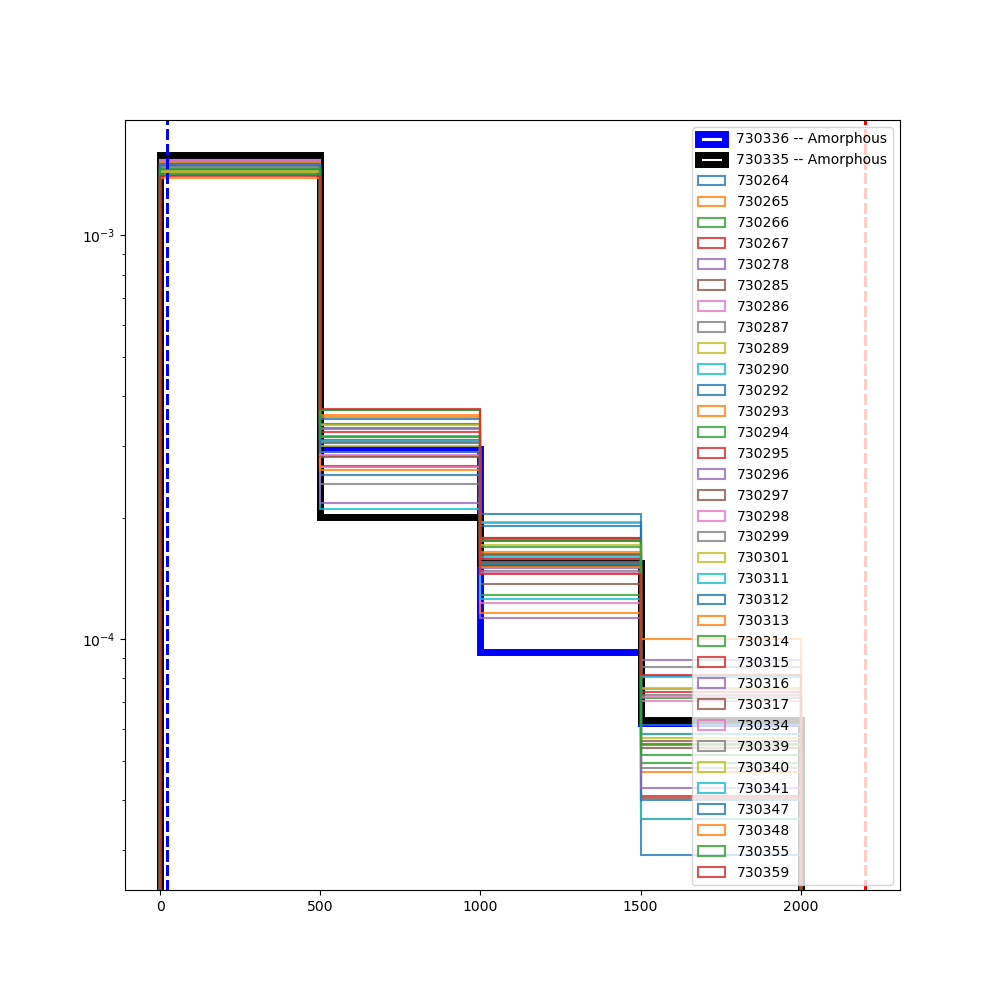

In [11]:
# Define what to compute
observables = ['ph', 'qtot', 'nclu', 'si', 'x3', 'y3', 'std_x3', 'std_y3']

Force_min_max = 'max' # 'min max 
photon_min = 20
# photon_max = 460 #250 ~ 1GeV
photon_max = 2200 #250 ~ 1GeV

show_plots = True

bins_hist = np.linspace(0,2000,5)
# Define conditional logic per observable
mask_modifiers = {
    'x3': lambda: (x3 > 3) & (x3 < 6) & (nclu[:, 0] == 1),
    'std_x3': lambda: (x3 > 3) & (x3 < 6) & (nclu[:, 0] == 1),
    'y3': lambda: (x3 > 3) & (x3 < 6) & (nclu[:, 0] == 1),  # optional
    'std_y3': lambda: (x3 > 3) & (x3 < 6) & (nclu[:, 0] == 1),
    'qtot': lambda: (nclu[:, 0] > 1),
    'si': lambda: (nclu[:, 0] > 1),
    'nclu': lambda: (nclu[:, 0] > 1),
    'ph': (
        lambda: (( ph_calo_photon <  photon_max) & (ph_calo_photon > photon_min))
    )
}

if show_plots:
    fig, ax = plt.subplots(1, figsize = (10,10))    
# Output dictionary: keyed by (rot, crad)
data_joint = {}
run_to_coord = {}

for i, run in enumerate(scan_number):
    # Load data
    if np.any(run) > 730198:
        xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1, \
        theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu, info_plus, xinfo = file_loader(run)
    else:
        _, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1, \
        theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu, info_plus, xinfo = file_loader(run)

    # Base mask
    base_mask = (ph_cherry1 > th_cherry1) & \
                (xcry > x_cry_cut[0]) & (xcry < x_cry_cut[1]) & \
                (ycry > y_cry_cut[0]) & (ycry < y_cry_cut[1]) & \
                (ph_calo_photon > th_calo) & \
                (abs(tm[:,2]-tm[:,0])-10 < 5) & \
                (((theta_x_in)**2 + (theta_y_in)**2) < (theta_cut**2))
    
    print(f'events in base mask: {np.sum(base_mask)}')
    if show_plots:
        if (run == 730335): 
            ax.hist(ph_calo_photon[base_mask],bins = bins_hist, density = True, label = f'{run} -- Amorphous', color = 'black', histtype= 'step',lw = 5)
        elif (run == 730336): 
            ax.hist(ph_calo_photon[base_mask],bins = bins_hist, density = True, label = f'{run} -- Amorphous', color = 'blue', histtype= 'step',lw = 5)
        else:
            ax.hist(ph_calo_photon[base_mask],bins = bins_hist, density = True, label = f'{run}', **opt_hist )
        ax.axvline(x = photon_min, c = 'b', ls = '--', lw = 2 ) 
        ax.axvline(x = photon_max, c = 'r', ls = '--', lw = 2 ) 
        ax.set_yscale('log')
        ax.legend()
    for obs in observables:
        # Combine base + modifier mask
        full_mask = base_mask & mask_modifiers[obs]()
        for i in np.where(full_mask)[0]:
            r = round(xinfo[i, 0], 6)
            c = round(xinfo[i, 1], 6)
            key = (r, c)
            if isinstance(run, (list, np.ndarray)):
                for run_id in run:
                    run_to_coord[run_id] = key
            else:
                run_to_coord[run] = key

            if key not in data_joint:
                data_joint[key] = {
                    'ph': [],'ph_hist': [],'ph_int': [], 'qtot': [], 'nclu': [], 'si': [],
                    'x3': [], 'y3': [], 'rot': r, 'crad': c
                }

            if obs == 'ph':
                data_joint[key]['ph'].append(ph_calo_photon[i])
            elif obs == 'qtot':
                data_joint[key]['qtot'].append(qtot[i, 0])
            elif obs == 'nclu':
                data_joint[key]['nclu'].append(nclu[i, 0])
            elif obs == 'si':
                # Compute single-event spectral intensity (approx.)
                data_joint[key]['si'].append(ph_calo_photon[i])  # can be refined
            elif obs == 'x3':
                data_joint[key]['x3'].append(x3[i])
            elif obs == 'y3':
                data_joint[key]['y3'].append(y3[i])


# === Calcola integrale normalizzato tra photon_min e photon_max per ciascun (rot, crad) ===
for key in data_joint:
    counts = data_joint[key].get('ph_hist', None)
    if counts is None or len(counts) != len(bins_hist) - 1:
        data_joint[key]['ph_int'] = np.nan
        continue

    integral = 0
    for i in range(len(counts)):
        bin_low = bins_hist[i]
        bin_high = bins_hist[i+1]

        # Bin completamente dentro il range
        if bin_low >= photon_min and bin_high <= photon_max:
            bin_width = bin_high - bin_low
            integral += counts[i] * bin_width

    data_joint[key]['ph_int'] = integral




In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from matplotlib.patches import Circle

# === PARAMETRI CONFIGURABILI ===
key_name = 'ph'         # 'ph', 'qtot', 'nclu', 'si', 'x3', 'y3', 'std_x3', 'std_y3'
skip_first = True           # Salta il primo punto nel fit
show_first = False          # Mostra il primo punto nei plot
plot_guesses = True
remove_point = False 

n_min = 10 ## 100 # 150 #250
# === RANGE DEL FIT (None per ignorare il filtro) ===
# fit_range_rot = (0,15000)     # esempio: (1000, 7000) None,None per non averli
fit_range_rot = (1600,12000)     # esempio: (1000, 7000) None,None per non averli
fit_range_crad = (32000, 52000)    # esempio: (30000, 37000)
# fit_range_crad = (None, None)    # esempio: (30000, 37000)

# Coordinate delle due rette
# blue_linex, blue_liney = [-1000, 9500], [50500, 31500]
# red_linex, red_liney = [-1000, 19000], [35000, 46000]


blue_linex, blue_liney = [-1000, 17000], [50000, 31500]
red_linex, red_liney = [-1000, 18000], [37000, 47500]
# blue_linex, blue_liney = [-1000, 17000], [41500, 41510] ## orrizontale
# red_linex, red_liney = [7250, 7300], [20000, 47000] ##verticale
###############################################################à

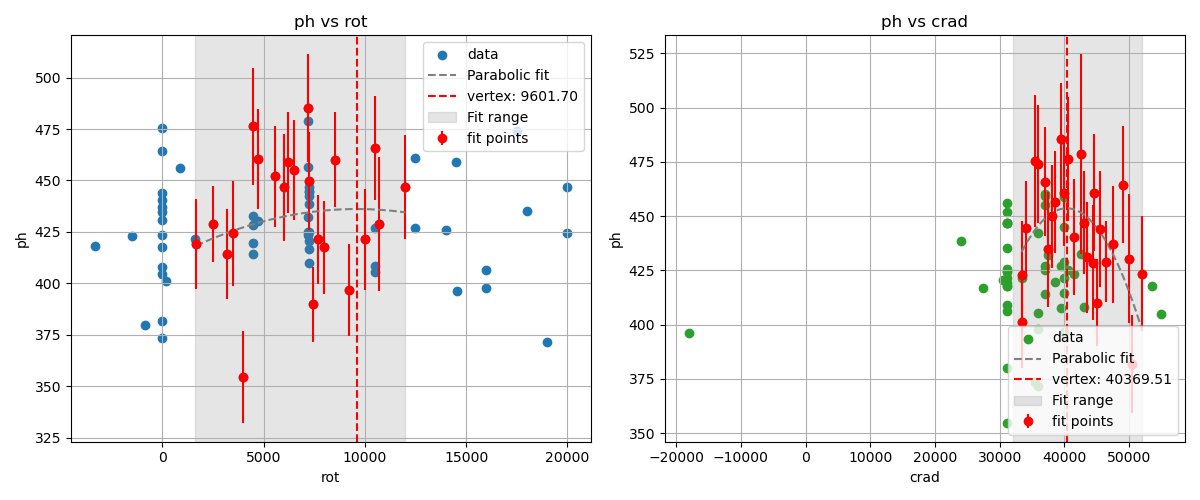

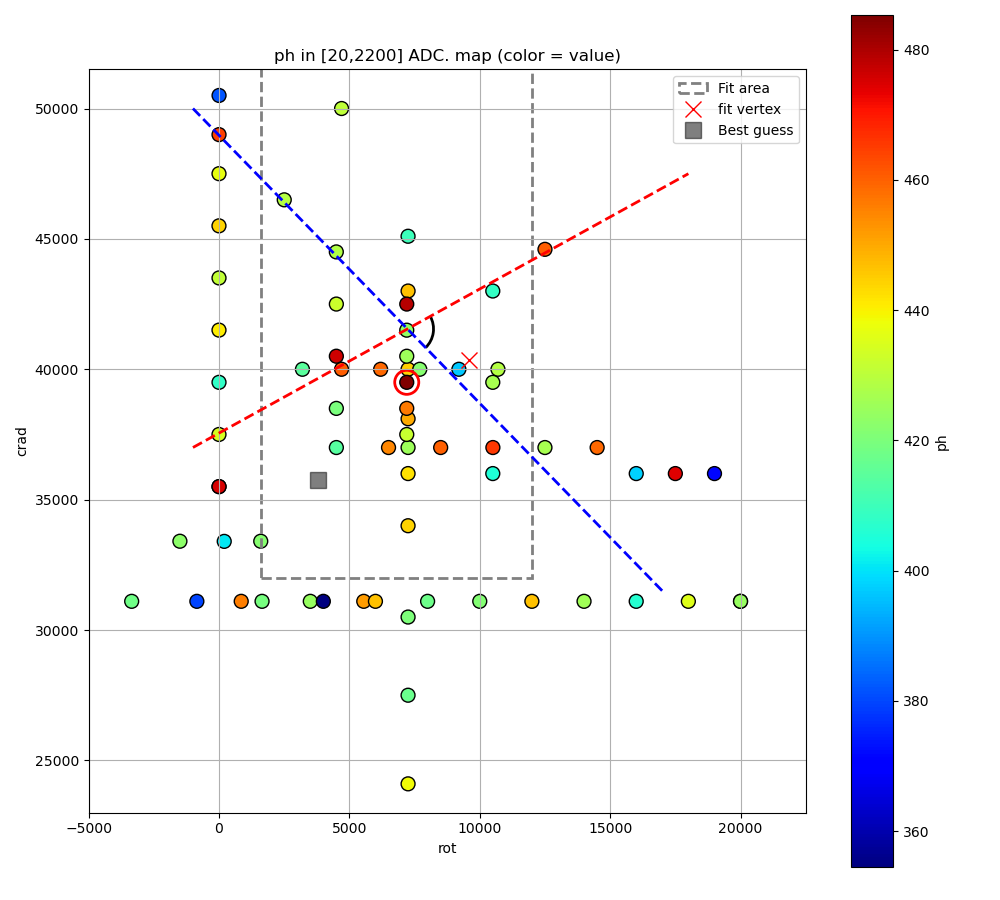

In [13]:
# === APPLICA RANGE AL FIT ===
def apply_fit_range(x, y, yerr, fit_range):
    if fit_range[0] is not None:
        mask = x >= fit_range[0]
    else:
        mask = np.ones_like(x, dtype=bool)
    if fit_range[1] is not None:
        mask &= x <= fit_range[1]
    return x[mask], y[mask], yerr[mask]

# === FUNZIONE PARABOLA PER IL FIT ===
def parabola(x, a, b, c):
    return a * x**2 + b * x + c

def safe_fit(x, y, yerr, force='max'):  # force: 'max', 'min', or None
    try:
        popt, pcov = curve_fit(parabola, x, y, sigma=yerr, absolute_sigma=True)
        
        if force == 'max' and popt[0] > 0:
            popt[0] *= -1
            popt[1] *= -1
        elif force == 'min' and popt[0] < 0:
            popt[0] *= -1
            popt[1] *= -1

        vertex = -popt[1] / (2 * popt[0])
        xfit = np.linspace(min(x), max(x), 300)
        yfit = parabola(xfit, *popt)
        return vertex, xfit, yfit, popt, pcov
    except Exception as e:
        print(f"[!] Fit failed: {e}")
        return np.nan, np.array([]), np.array([]), None, None



# === COSTRUISCI ARRAY DEI RISULTATI ===
results = []
for (r, c), values in data_joint.items():
        # Seleziona i dati da usare (media o deviazione)
    if key_name.startswith("std_"):
        arr = values[key_name[4:]]
    else:
        arr = values[key_name]
    # print(f'{(r,c)} -- {len(arr)}') 
    # Filtro: escludi se troppo pochi eventi
    if len(arr) < n_min:
        continue  # salta la coppia (r, c)

    # Calcolo valore
    val = np.std(arr) if key_name.startswith("std_") else np.mean(arr)

    # Filtro opzionale su punto specifico
    if remove_point and (np.abs(r - 7200) < 20 and np.abs(c - 42500) < 300):
        continue
    results.append((r, c, val))


results = np.array(results)
r_vals = results[:, 0]
c_vals = results[:, 1]
z_vals = results[:, 2]

# === ROUND A ROT E CRAD ALLA DECINA (-1) o al CENTINAIO (-2) ===
r_rounded = np.round(r_vals, -1)
c_rounded = np.round(c_vals, -1)

# === TROVA VALORI MASSIMI DI Z PER OGNI ROT TONDA E CRAD TONDA ===
unique_r = np.unique(r_rounded)
unique_c = np.unique(c_rounded)

r_best = []
z_r_best = []
n_r_best = []
for r in unique_r:
    mask = r_rounded == r
    if Force_min_max == 'max':
        idx = np.nanargmax(z_vals[mask])
    else:
        idx = np.nanargmin(z_vals[mask])
    r_best.append(r_vals[mask][idx])
    z_r_best.append(z_vals[mask][idx])
    n_r_best.append(len(data_joint[(r_vals[mask][idx], c_vals[mask][idx])][key_name if not key_name.startswith("std_") else key_name[4:]]))


c_best = []
z_c_best = []
n_c_best = []
for c in unique_c:
    mask = c_rounded == c
    if Force_min_max == 'max':
        idx = np.nanargmax(z_vals[mask])
    else:
        idx = np.nanargmin(z_vals[mask])
    c_best.append(c_vals[mask][idx])
    z_c_best.append(z_vals[mask][idx])
    n_c_best.append(len(data_joint[(r_vals[mask][idx], c_vals[mask][idx])][key_name if not key_name.startswith("std_") else key_name[4:]]))


# === RIMUOVI IL PRIMO PUNTO SE skip_first ===
r_best = np.array(r_best)
z_r_best = np.array(z_r_best)
n_r_best = np.array(n_r_best)

c_best = np.array(c_best)
z_c_best = np.array(z_c_best)
n_c_best = np.array(n_c_best)

if skip_first:
    r_best = r_best[1:]
    z_r_best = z_r_best[1:]
    n_r_best = n_r_best[1:]

    c_best = c_best[1:]
    z_c_best = z_c_best[1:]
    n_c_best = n_c_best[1:]


# === APPLICA RANGE AL FIT ===
r_best = np.array(r_best)
z_r_best = np.array(z_r_best)
n_r_best = np.array(n_r_best)
z_r_err = z_r_best / np.sqrt(n_r_best)

c_best = np.array(c_best)
z_c_best = np.array(z_c_best)
n_c_best = np.array(n_c_best)
z_c_err = z_c_best / np.sqrt(n_c_best)

# Applica filtro range
r_best, z_r_best, z_r_err = apply_fit_range(r_best, z_r_best, z_r_err, fit_range_rot)
c_best, z_c_best, z_c_err = apply_fit_range(c_best, z_c_best, z_c_err, fit_range_crad)

# === FIT ===
vertex_rot, xfit_rot, yfit_rot, _, _ = safe_fit(r_best, z_r_best, z_r_err, force=Force_min_max)
vertex_crad, xfit_crad, yfit_crad, _, _ = safe_fit(c_best, z_c_best, z_c_err, force=Force_min_max)

# === PLOT 1D CON OVERLAY ===
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- ROT ---
mask_plot = np.ones_like(r_vals, dtype=bool) if show_first else (r_vals != r_vals.min())
ax[0].scatter(r_vals[mask_plot], z_vals[mask_plot], c='tab:blue', label='data')
ax[0].errorbar(r_best, z_r_best, yerr=z_r_err, fmt='o', color='red', label='fit points')
if len(xfit_rot) > 0:
    ax[0].plot(xfit_rot, yfit_rot, '--', color='gray', label='Parabolic fit')
    ax[0].axvline(vertex_rot, color='red', linestyle='--', label=f'vertex: {vertex_rot:.2f}')
# Overlay grigio sul range selezionato
if fit_range_rot[0] is not None and fit_range_rot[1] is not None:
    ax[0].axvspan(fit_range_rot[0], fit_range_rot[1], color='gray', alpha=0.2, label='Fit range')

ax[0].set_xlabel('rot')
ax[0].set_ylabel(key_name)
ax[0].set_title(f'{key_name} vs rot')
ax[0].grid(True)
ax[0].legend()

# --- CRAD ---
mask_plot = np.ones_like(c_vals, dtype=bool) if show_first else (c_vals != c_vals.min())
ax[1].scatter(c_vals[mask_plot], z_vals[mask_plot], c='tab:green', label='data')
ax[1].errorbar(c_best, z_c_best, yerr=z_c_err, fmt='o', color='red', label='fit points')
if len(xfit_crad) > 0:
    ax[1].plot(xfit_crad, yfit_crad, '--', color='gray', label='Parabolic fit')
    ax[1].axvline(vertex_crad, color='red', linestyle='--', label=f'vertex: {vertex_crad:.2f}')
# Overlay grigio sul range selezionato
if fit_range_crad[0] is not None and fit_range_crad[1] is not None:
    ax[1].axvspan(fit_range_crad[0], fit_range_crad[1], color='gray', alpha=0.2, label='Fit range')

ax[1].set_xlabel('crad')
ax[1].set_ylabel(key_name)
ax[1].set_title(f'{key_name} vs crad')
ax[1].grid(True)
ax[1].legend(loc='lower right')

fig.tight_layout()
plt.show()
from matplotlib.patches import Rectangle

# === PLOT 2D MAP ===
fig2, ax2 = plt.subplots(figsize=(10, 9))
from matplotlib.colors import LogNorm

# Filtro valori non-positivi per la scala log
z_for_log = np.copy(z_vals)
z_for_log[z_for_log <= 0] = np.nanmin(z_vals[z_vals > 0]) * 0.1  # evita log(0)

sc = ax2.scatter(r_vals, c_vals, c=z_for_log, cmap='jet', edgecolors='k', s = 100) # norm=LogNorm()

ax2.set_xlabel('rot')
ax2.set_ylabel('crad')
if 'ph' in key_name : 
    ax2.set_title(f'{key_name} in [{photon_min},{photon_max}] ADC. map (color = value)')
else:
    ax2.set_title(f'{key_name} map (color = value)')
plt.colorbar(sc, ax=ax2, label=key_name)

# === AGGIUNGI RIQUADRO FIT AREA SE DEFINITO ===
if fit_range_rot[0] is not None and fit_range_rot[1] is not None and \
   fit_range_crad[0] is not None and fit_range_crad[1] is not None:
    
    rect = Rectangle(
        (fit_range_rot[0], fit_range_crad[0]),
        fit_range_rot[1] - fit_range_rot[0],
        fit_range_crad[1] - fit_range_crad[0],
        linewidth=2,
        edgecolor='gray',
        facecolor='none',
        linestyle='--',
        label='Fit area'
    )
    ax2.add_patch(rect)



# Trova il punto con z massimo
idx_max = np.nanargmax(z_vals)
x_max = r_vals[idx_max]
y_max = c_vals[idx_max]
idx_min = np.nanargmin(z_vals)
x_min = r_vals[idx_min]
y_min = c_vals[idx_min]

# Crea un cerchio rosso trasparente
if Force_min_max == 'max':
    plt.scatter(x_max, y_max, s=300, facecolors='none', edgecolors='r', linewidths=2)
elif Force_min_max == 'min':
    plt.scatter(x_min, y_min, s=300, facecolors='none', edgecolors='b', linewidths=2)
    

# Aggiungi X rossa su (vertex_rot, vertex_crad)
if plot_guesses:
    if not np.isnan(vertex_rot) and not np.isnan(vertex_crad):
        ax2.plot(vertex_rot, vertex_crad, 'rx', markersize=12, label='fit vertex')
        ax2.plot(3780, 35750, 'ks', markersize=12, label='Best guess', alpha = 0.5)
        # ax2.plot(-3350, 31100, 'b^', markersize=12, label='Best guess + beam')
        # ax2.plot(215, 33425, 'gx', markersize=12, label='average')/
    ax2.legend()
    # ax2.legend()
# ax2.plot(6500,37000,'ks', alpha = 0.5, markersize = 12, label= 'Laura e Marco guess')

# ax2.set_xlim(-3000,20500)
# ax2.set_ylim(32000,32000+24500)

###############################################################à
ax2.set_xlim(-5000,22500)
ax2.set_ylim(23000,24000+27500)

# Tracciamento delle rette

from matplotlib.patches import Arc

# Calcolo coefficienti angolari
m1 = (red_liney[1] - red_liney[0]) / (red_linex[1] - red_linex[0])
m2 = (blue_liney[1] - blue_liney[0]) / (blue_linex[1] - blue_linex[0])

# Calcolo intercette
q1 = red_liney[0] - m1 * red_linex[0]
q2 = blue_liney[0] - m2 * blue_linex[0]

# Calcolo punto di intersezione tra le due rette
xi = (q2 - q1) / (m1 - m2)
yi = m1 * xi + q1

# Calcolo angolo tra le due rette
theta_rad = np.arctan(abs((m1 - m2) / (1 + m1 * m2)))
theta_deg = np.degrees(theta_rad)

# Calcolo angoli assoluti delle due rette rispetto all'orizzontale
angle1 = np.degrees(np.arctan(m1))
angle2 = np.degrees(np.arctan(m2))

# Trova l'angolo minore tra i due (per disegnare l'arco nel modo corretto)
theta1 = min(angle1, angle2)
theta2 = max(angle1, angle2)

# Tracciamento rette
ax2.plot(red_linex, red_liney, color='red', linestyle='--', linewidth=2)
ax2.plot(blue_linex, blue_liney, color='blue', linestyle='--', linewidth=2)

# Arco che rappresenta l’angolo
arc_radius = 2000
arc = Arc((xi, yi), arc_radius, arc_radius, angle=0,
          theta1=theta1, theta2=theta2,
          color='black', linewidth=2)
ax2.add_patch(arc)

# Etichetta dell'angolo
# ax2.text(xi + 500 + arc_radius * 0.5, yi -200 + arc_radius * 0.2,
#         f'{theta_deg:.1f}°', color='black', fontsize=15)

# Altri dettagli grafici
ax2.legend()
ax2.grid(True)
ax2.set_aspect('equal', adjustable='box')  # per rappresentare correttamente l'arco

plt.tight_layout()
plt.show()

fig.savefig(f'crad-rot{Force_min_max}.png')
fig2.savefig(f'stereo{Force_min_max}.png')

730292
Run 730292 — N spill: 50 — events: 10591 — evs/spill: 212
[730292] — TOTAL SPILLS: 50 — TOTAL EVENTS: 10450
730335
Run 730335 — N spill: 50 — events: 9953 — evs/spill: 199
[730335] — TOTAL SPILLS: 50 — TOTAL EVENTS: 9837


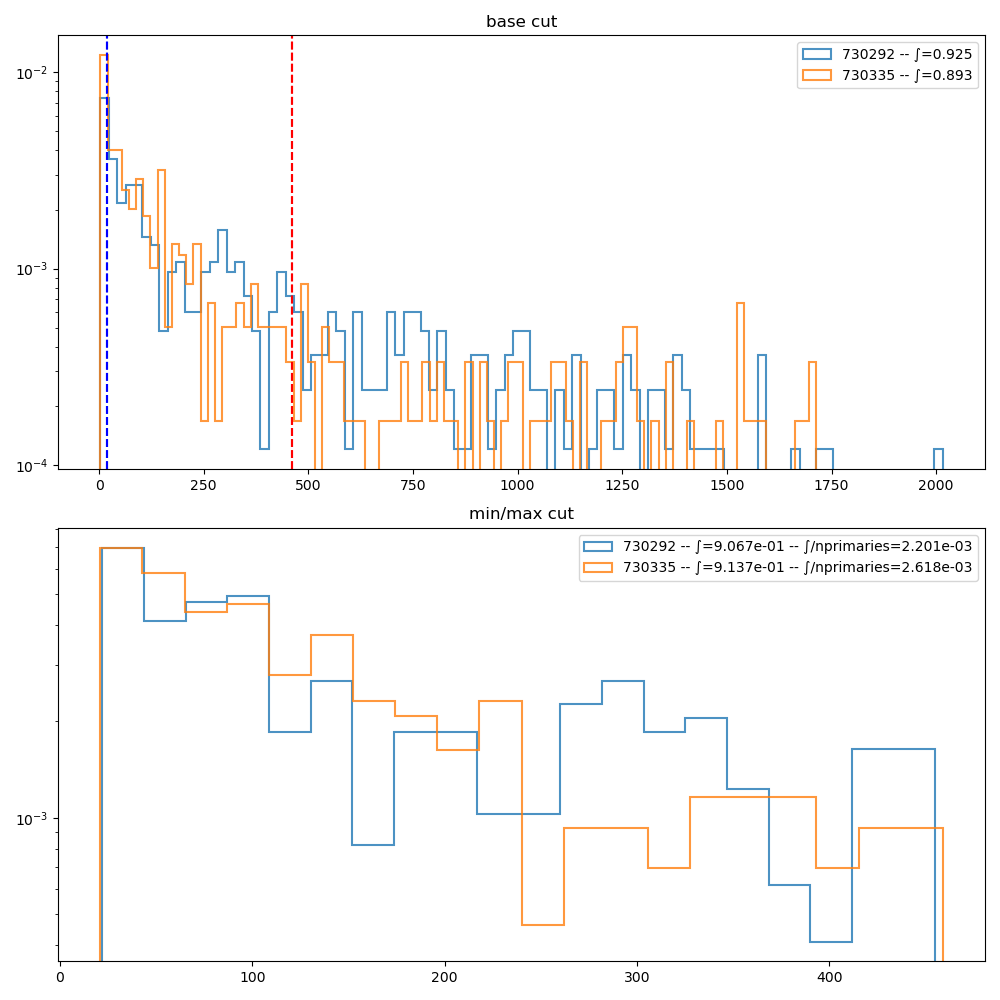

In [7]:
check_run = [730292, 730335]
fig, ax = plt.subplots(2, figsize=(10, 10))
photon_max_l = 460
photon_min_l = 20

nbins_base = 100
nbins_cut= 20

for i, run in enumerate(check_run):
    print(run)
    # Load data
    if np.any(run) > 730198:
        xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1, \
        theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu, info_plus, xinfo = file_loader(run)
    else:
        _, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1, \
        theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu, info_plus, xinfo = file_loader(run)

    # Base mask
    base_mask = (ph_cherry1 > th_cherry1) & \
                (xcry > x_cry_cut[0]) & (xcry < x_cry_cut[1]) & \
                (ycry > y_cry_cut[0]) & (ycry < y_cry_cut[1]) & \
                (ph_calo_photon > th_calo) & \
                (abs(tm[:,2]-tm[:,0])-10 < 5) & \
                (((theta_x_in)**2 + (theta_y_in)**2) < (theta_cut**2))

    # Calcolo istogramma base con density=True
    h_base, bins_base = np.histogram(ph_calo_photon[base_mask], bins=nbins_base, density=True)
    bin_centers = 0.5 * (bins_base[:-1] + bins_base[1:])
    integral_trapz = np.trapz(h_base, bin_centers)
    primaries_after_cuts = np.sum(base_mask)

    ax[0].hist(ph_calo_photon[base_mask], label=f'{run} -- ∫={integral_trapz:.3f}', bins=nbins_base, density=True, **opt_hist)
    ax[0].set_title('base cut')
    ax[0].legend()
    ax[0].set_yscale('log')
    ax[0].axvline(photon_min_l, c = 'b', ls = '--')
    ax[0].axvline(photon_max_l, c = 'r', ls = '--')

    # Istogramma con cut min/max
    mask_cut = base_mask & ((ph_calo_photon < photon_max_l) & (ph_calo_photon > photon_min_l))
    
    h_cut, bins_cut = np.histogram(ph_calo_photon[mask_cut], bins=nbins_cut, density=True)
    bin_centers = 0.5 * (bins_cut[:-1] + bins_cut[1:])
    integral_trapz_cut = np.trapz(h_cut, bin_centers)
        
    ax[1].hist(ph_calo_photon[mask_cut], label=f'{run} -- ∫={integral_trapz_cut:.3e} -- ∫/nprimaries={(integral_trapz_cut/primaries_after_cuts):.3e}', bins=nbins_cut, density=True, **opt_hist)
    ax[1].set_title('min/max cut')
    ax[1].legend()
    ax[1].set_yscale('log')

plt.tight_layout()
plt.show()


In [8]:
photon_max_l = 2200 ## 2200 # 460
photon_min_l = 20

nbins_base = 100
nbins_cut= 20

integral_l = {}

for i, run in enumerate(scan_number):
    print(run)
    # Load data
    if np.any(run) > 730198:
        xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1, \
        theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu, info_plus, xinfo = file_loader(run)
    else:
        _, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1, \
        theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu, info_plus, xinfo = file_loader(run)

    base_mask = (ph_cherry1 > th_cherry1) & \
                (xcry > x_cry_cut[0]) & (xcry < x_cry_cut[1]) & \
                (ycry > y_cry_cut[0]) & (ycry < y_cry_cut[1]) & \
                (ph_calo_photon > th_calo) & \
                (abs(tm[:,2]-tm[:,0])-10 < 5) & \
                (((theta_x_in)**2 + (theta_y_in)**2) < (theta_cut**2))

    r_vals = np.round(xinfo[:, 0], 0)
    c_vals = np.round(xinfo[:, 1], 0)
    unique_keys = set(zip(r_vals, c_vals))

    for r, c in unique_keys:
        rc_mask = base_mask & (r_vals == r) & (c_vals == c)
        if np.sum(rc_mask) < 230:
            continue

        primaries = np.sum(rc_mask)

        # Histogram with cut
        mask_cut = rc_mask & (ph_calo_photon > photon_min_l) & (ph_calo_photon < photon_max_l)
        if np.sum(mask_cut) < 200:
            continue
        h_cut, bins_cut = np.histogram(ph_calo_photon[mask_cut], bins=nbins_cut, density=True)
        bin_centers = 0.5 * (bins_cut[:-1] + bins_cut[1:])
        integral_cut = np.trapz(h_cut, bin_centers)

        key = (r, c)
        integral_l[key] = 1000*integral_cut / primaries

        # print(f"Run {run} - r={r}, c={c} | primaries: {primaries}, mask_cut: {np.sum(mask_cut)}, integral/primaries: {integral_cut / primaries:.3e}")
        if integral_l[key] > 3:
            print('\n##############################')
            print(f'{r}{c} -- {integral_l[key]} -- | primaries: {primaries}, mask_cut: {np.sum(mask_cut)}')
            print('##############################\n')

730336
Run 730336 — N spill: 84 — events: 16495 — evs/spill: 196
[730336] — TOTAL SPILLS: 84 — TOTAL EVENTS: 16295
730335
Run 730335 — N spill: 50 — events: 9953 — evs/spill: 199
[730335] — TOTAL SPILLS: 50 — TOTAL EVENTS: 9837
730264
Run 730264 — N spill: 47 — events: 10119 — evs/spill: 215
[730264] — TOTAL SPILLS: 47 — TOTAL EVENTS: 9991
730265
Run 730265 — N spill: 37 — events: 10408 — evs/spill: 281
[730265] — TOTAL SPILLS: 37 — TOTAL EVENTS: 10284
730266
Run 730266 — N spill: 45 — events: 11751 — evs/spill: 261
[730266] — TOTAL SPILLS: 45 — TOTAL EVENTS: 11585
730267
Run 730267 — N spill: 41 — events: 9969 — evs/spill: 243
[730267] — TOTAL SPILLS: 41 — TOTAL EVENTS: 9857
730278
Run 730278 — N spill: 41 — events: 8148 — evs/spill: 199
[730278] — TOTAL SPILLS: 41 — TOTAL EVENTS: 8036
730285
Run 730285 — N spill: 39 — events: 7276 — evs/spill: 187
[730285] — TOTAL SPILLS: 39 — TOTAL EVENTS: 7170

##############################
-850.031101.0 -- 3.3760651247717592 -- | primaries: 248, 

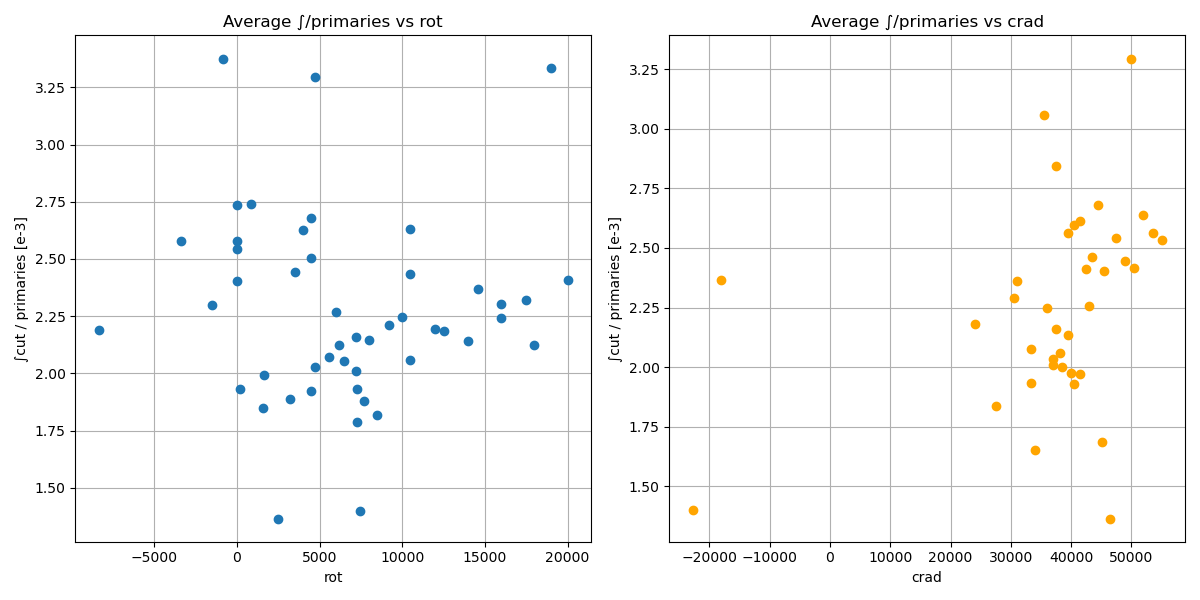

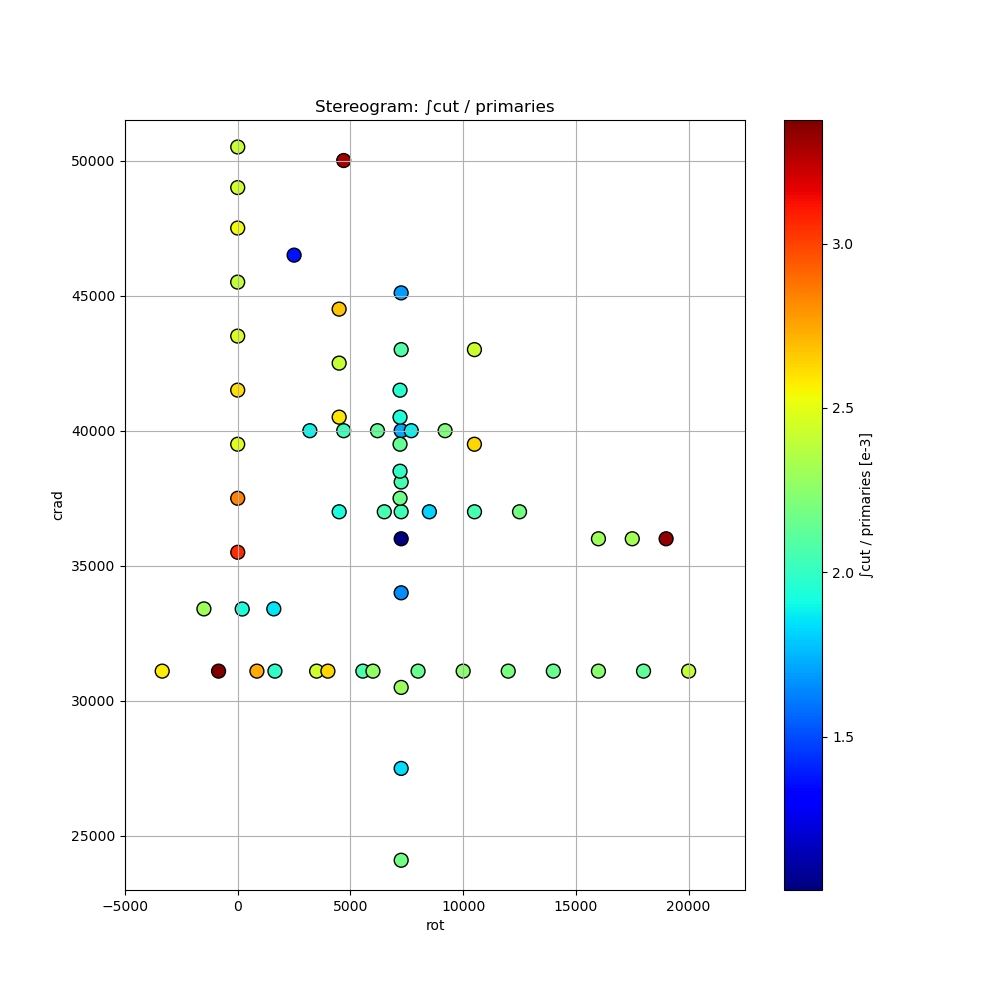

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Estrai r, c e z da integral_l
r_vals = np.array([k[0] for k in integral_l.keys()])
c_vals = np.array([k[1] for k in integral_l.keys()])
z_vals = np.array(list(integral_l.values()))

# Crea figura con 3 subplot
fig2, axs2 = plt.subplots(1,figsize=(10, 10))
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# === Stereogramma ===
sc = axs2.scatter(r_vals, c_vals, c=z_vals, cmap='jet', s=100, edgecolors='k')
fig.colorbar(sc, ax=axs2, label='∫cut / primaries [e-3]')
axs2.set_xlabel('rot')
axs2.set_ylabel('crad')
axs2.set_title('Stereogram: ∫cut / primaries')
axs2.grid(True)

# === ∫/primaries vs rot ===
df = pd.DataFrame({'rot': r_vals, 'crad': c_vals, 'z': z_vals})
rot_avg = df.groupby('rot')['z'].mean().reset_index()
axs[0].plot(rot_avg['rot'], rot_avg['z'], marker='o', ls = '')
axs[0].set_xlabel('rot')
axs[0].set_ylabel('∫cut / primaries [e-3]')
axs[0].set_title('Average ∫/primaries vs rot')
axs[0].grid(True)

# === ∫/primaries vs crad ===
crad_avg = df.groupby('crad')['z'].mean().reset_index()
axs[1].plot(crad_avg['crad'], crad_avg['z'], marker='o', color='orange', ls = '')
axs[1].set_xlabel('crad')
axs[1].set_ylabel('∫cut / primaries [e-3]')
axs[1].set_title('Average ∫/primaries vs crad')
axs[1].grid(True)

###############################################################à
axs2.set_xlim(-5000,22500)
axs2.set_ylim(23000,24000+27500)


plt.tight_layout()
plt.show()
